In [1]:
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
from enum import Enum

# Scalping strategy.
Two SMA will be used to define the trend. And the bollinger bands indicator will be used to set the confirme the trading logic. If the price is below the lower bollinger band it may be a buy signal, like wise if the price is above the upper bollinger band it may be a sell signal.

The bollinger band and trend SMA will be combined to a trading signal. 

## Loade data

In [2]:
df_GOLD_Raw = pd.read_parquet(f"../Data/GOLD_1M.parquet")
df_baseline = pd.read_parquet(f"../Data/EURUSD_M1.parquet")
df_GOLD_Raw.head()

,open,high,low,close,volume
time,,,,,
2019-10-15 12:13:00,1492.87,1493.36,1492.77,1493.33,62
2019-10-15 12:14:00,1493.36,1493.47,1493.06,1493.07,47
2019-10-15 12:15:00,1493.09,1493.28,1492.97,1493.07,70
2019-10-15 12:16:00,1493.08,1493.35,1493.07,1493.35,28
2019-10-15 12:17:00,1493.30,1493.36,1493.14,1493.28,38


In [3]:
def get_resampled(df, high_freq='4h'):
    volume_col = 'tick_volume' if 'tick_volume' in df.columns else 'volume'

    df_high_sample_rate = df.resample(high_freq).agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        volume=(volume_col, 'sum'),
        High_time=('high', lambda x: x.idxmax() if len(x) > 0 else None),
        Low_time=('low', lambda x: x.idxmin() if len(x) > 0 else None)
    )

    df_high_sample_rate = df_high_sample_rate.dropna()

    return df_high_sample_rate

In [4]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
df_baseline = get_resampled(df_baseline, high_freq="5min")

## Build strategy

In [5]:
class TimeFrame(Enum):
  DAILY = 252
  MIN_1 = 252 * 24 * 60
  MIN_5 = 252 * 24 * 12
  MIN_10 = 252 * 24 * 6
  HOUR_1 = 252 * 24
  HOUR_6 = 252 * 4

selected_timeframe = TimeFrame.MIN_5

def drawdown_function(returns):

  # Build an equity curve from periodic returns, then compute peak-to-trough drawdown
  equity_curve = (1 + returns.dropna()).cumprod()
  running_max = equity_curve.cummax()
  drawdown = equity_curve / running_max - 1
  return drawdown

def BackTest(strategy_data, baseline_data, annualiazed_scalar=selected_timeframe):

  # Accept either enum or numeric annualization scalar
  annualized_scalar = annualiazed_scalar.value if isinstance(annualiazed_scalar, Enum) else float(annualiazed_scalar)

  # Ensure a clean strategy return series
  serie = strategy_data.copy()
  if isinstance(serie, pd.DataFrame):
    if "return" in serie.columns:
      serie = serie["return"]
    else:
      serie = serie.iloc[:, 0]
  serie = serie.rename("return").dropna()
  if not serie.index.is_unique:
    serie = serie[~serie.index.duplicated(keep="first")]

  # Build benchmark return series from close prices
  if isinstance(baseline_data, pd.DataFrame):
    if "close" in baseline_data.columns:
      baseline_price = baseline_data["close"]
    else:
      baseline_price = baseline_data.iloc[:, 0]
  else:
    baseline_price = baseline_data

  baseline = baseline_price.pct_change(1).rename("EURUSD").dropna()
  if not baseline.index.is_unique:
    baseline = baseline[~baseline.index.duplicated(keep="first")]

  # Align by timestamps to avoid mixing unrelated bars
  val = pd.concat((serie, baseline), axis=1, join="inner").dropna()
  if val.empty:
    raise ValueError("No overlapping timestamps between strategy and benchmark after alignment.")

  # Final compounded returns
  final_return_portfolio = (1 + val["return"]).prod() - 1
  final_return_benchmark = (1 + val["EURUSD"]).prod() - 1

  # Compute drawdown on aligned strategy returns
  drawdown = drawdown_function(val["return"]) * 100

  # Compute max drawdown
  max_drawdown = -np.min(drawdown)

  # Put a subplots
  fig, (cum, dra) = plt.subplots(1, 2, figsize=(20, 6))

  # Put a Suptitle
  fig.suptitle("Backtesting", size=20)

  # Returns equity curves
  cum.plot(((1 + val["return"]).cumprod() - 1) * 100, color="#39B3C7")

  # EURUSD equity curve
  cum.plot(((1 + val["EURUSD"]).cumprod() - 1) * 100, color="#B85A0F")

  # Put a legend
  cum.legend(["Portfolio", "EURUSD"])

  # Set individual title
  cum.set_title("Cumulative Return", size=13)

  cum.set_ylabel("Cumulative Return %", size=11)

  # Put the drawdown
  dra.fill_between(drawdown.index, 0, drawdown, color="#C73954", alpha=0.65)

  # Set individual title
  dra.set_title("Drawdown", size=13)

  dra.set_ylabel("drawdown in %", size=11)

  # Plot the graph
  plt.show()

  # Compute the sortino
  downside_std = val.loc[val["return"] < 0, "return"].std()
  sortino = np.nan if (pd.isna(downside_std) or downside_std == 0) else np.sqrt(annualized_scalar) * val["return"].mean() / downside_std

  # Compute the beta
  benchmark_var = np.var(val["EURUSD"].values)
  beta = np.nan if benchmark_var == 0 else np.cov(val[["return", "EURUSD"]].values, rowvar=False)[0][1] / benchmark_var

  # Compute the alpha
  alpha = np.nan if pd.isna(beta) else annualized_scalar * (val["return"].mean() - beta * val["EURUSD"].mean())

  # Print the statistics
  print(f"Final Return Portfolio: {final_return_portfolio:.2%}")
  print(f"Final Return EURUSD: {final_return_benchmark:.2%}")
  print(f"Sortino: {np.round(sortino,3)}")
  print(f"Beta: {np.round(beta,3)}")
  print(f"Alpha: {np.round(alpha*100,3)} %")
  print(f"MaxDrawdown: {np.round(max_drawdown,3)} %")

  return {
    "final_return_portfolio": final_return_portfolio,
    "final_return_benchmark": final_return_benchmark,
    "sortino": sortino,
    "beta": beta,
    "alpha": alpha,
    "max_drawdown": max_drawdown,
  }

def Scalping_strategy(df=df_GOLD_Raw, SMA_Fast = 30, SMA_Slow = 60, bb_length=15, bb_std=2, transaction_cost=0.0):
  
  df = df.copy()

  # Create fast and slow SMAs
  df["EMA_fast"] = df["close"].ewm(span=SMA_Fast, adjust=False).mean()
  df["EMA_slow"] = df["close"].ewm(span=SMA_Slow, adjust=False).mean()

  bb = df.ta.bbands(length= bb_length, std=bb_std)

  bb.columns = ["bb_lower", "bb_mid", "bb_upper", "bb_width", "bb_percent"]

  df = pd.concat([df, bb], axis=1)

  backcandles = 7

  cond_below = df["EMA_fast"] < df["EMA_slow"]
  cond_above = df["EMA_fast"] > df["EMA_slow"]

  # Rolling checks
  all_below = cond_below.rolling(window=backcandles).sum() == backcandles
  all_above = cond_above.rolling(window=backcandles).sum() == backcandles

  # Build signal
  df["EMASignal"] = 0
  df.loc[all_below, "EMASignal"] = 1
  df.loc[all_above, "EMASignal"] = 2

  df['position'] = np.nan
  df.loc[(df['EMASignal'] == 1) & (df['bb_lower']<df['close']), 'position'] = 1
  df.loc[(df['EMASignal'] == 2) & (df['bb_upper']>df['close']), 'position'] = -1
  df['position'] = df['position'].ffill().fillna(0)


  # Keep previous position between signals, then flat before first signal
  df["position"] = df["position"].ffill().fillna(0)

  df["pct"] = df["close"].pct_change(1)

  # Apply transaction cost only when a position change occurs
  turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
  df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

  # Keep only valid strategy returns; avoids plotting an all-NaN series
  ret = df["return"].dropna()
  if ret.empty:
    raise ValueError("No valid returns. Download more history or reduce SMA windows.")

  return ret

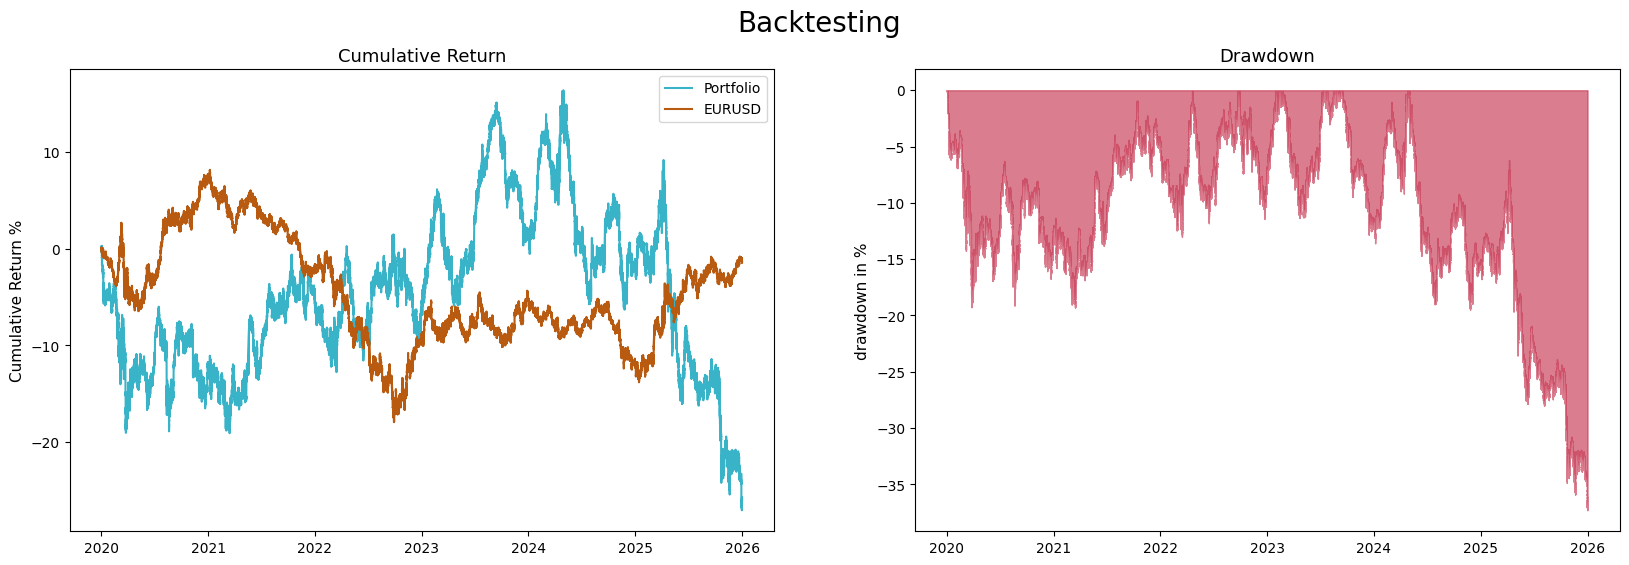

Final Return Portfolio: -25.84%
Final Return EURUSD: -1.29%
Sortino: -0.311
Beta: -0.001
Alpha: -3.896 %
MaxDrawdown: 37.306 %


In [6]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
dfc = Scalping_strategy(df_GOLD, SMA_Fast = 30, SMA_Slow = 60, bb_length=15, bb_std=2, transaction_cost=0.00001)
metrics = BackTest(dfc, df_baseline, selected_timeframe)